In [1]:
import pandas as pd 
import numpy as np
import os
import cv2
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from tqdm.notebook import tqdm
from sklearn.utils import shuffle
from sklearn.metrics import classification_report,accuracy_score,RocCurveDisplay,confusion_matrix,roc_auc_score
from sklearn.preprocessing import LabelBinarizer,LabelEncoder,label_binarize
from sklearn.model_selection import GridSearchCV,train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model,Sequential,save_model
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ReduceLROnPlateau,EarlyStopping,ModelCheckpoint


In [3]:
BASE_DIR = os.path.abspath("")

In [6]:
df_train= pd.read_csv("train_labels.csv")
df_test= pd.read_csv("test_labels.csv")

In [7]:
classes = ["surprise","fear","disgust","happy","sad","angry","neutral"]
label_map = {label :(idx+1) for idx,label in enumerate(classes)}
print(label_map)

{'surprise': 1, 'fear': 2, 'disgust': 3, 'happy': 4, 'sad': 5, 'angry': 6, 'neutral': 7}


In [25]:
import os
import cv2
import numpy as np

# 1. Base Project Directory
BASE_DIR = r"c:\Users\Dell\Desktop\Emotional_Detector.project"

# 2. EXACT MATCH: Jo tumhare tree output mein aaya hai wahi exact case
DATASET_DIR = os.path.join(BASE_DIR, "DATASET") # All capital letters
TRAIN_DIR = os.path.join(DATASET_DIR, "train")   # lowercase t
TEST_DIR = os.path.join(DATASET_DIR, "test")     # lowercase t

print("--- Confirmed System Paths ---")
print("Train Path:", TRAIN_DIR)
print("Test Path:", TEST_DIR)

# 3. Final & Fixed Data Loader
def load_data(dataset_dir, label_map):
    images = []
    labels = []
    
    if not os.path.exists(dataset_dir):
        print(f"Error: Path nahi mila -> {dataset_dir}")
        return np.array(images), np.array(labels)
        
    # Tree ke mutabik folders ke naam '1', '2' hain, isliye hum folder_num ko target karenge
    for label_name, folder_num in label_map.items():
        folder_path = os.path.join(dataset_dir, str(folder_num))
        
        if os.path.exists(folder_path):
            print(f"Loading Folder '{folder_num}' for emotion: {label_name}")
            
            for filename in os.listdir(folder_path):
                img_path = os.path.join(folder_path, filename)
                img = cv2.imread(img_path)
                if img is not None:
                    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    images.append(img_rgb)
                    labels.append(folder_num)
        else:
            # Agar koi number folder miss ho toh warning dega
            print(f"⚠️ Note: Folder '{folder_num}' nahi mila inside {dataset_dir}")
            
    return np.array(images), np.array(labels)

# --- Execution ---
# Yeh map exact tumhare numbered subfolders ('1', '2', etc.) ko read karega
label_map = {
    'surprise': 1, 
    'fear': 2, 
    'disgust': 3, 
    'happy': 4, 
    'sad': 5, 
    'angry': 6,
    'neutral': 7
}

print("\n--- Starting Data Extraction ---")
print("\n[Loading Train Dataset...]")
train_images, train_labels = load_data(TRAIN_DIR, label_map)

print("\n[Loading Test Dataset...]")
test_images, test_labels = load_data(TEST_DIR, label_map)

print("\n--- Final Summary ---")
print(f"Total Train Images Loaded: {len(train_images)}")
print(f"Total Test Images Loaded: {len(test_images)}")

--- Confirmed System Paths ---
Train Path: c:\Users\Dell\Desktop\Emotional_Detector.project\DATASET\train
Test Path: c:\Users\Dell\Desktop\Emotional_Detector.project\DATASET\test

--- Starting Data Extraction ---

[Loading Train Dataset...]
Loading Folder '1' for emotion: surprise
Loading Folder '2' for emotion: fear
Loading Folder '3' for emotion: disgust
Loading Folder '4' for emotion: happy
Loading Folder '5' for emotion: sad
Loading Folder '6' for emotion: angry
Loading Folder '7' for emotion: neutral

[Loading Test Dataset...]
Loading Folder '1' for emotion: surprise
Loading Folder '2' for emotion: fear
Loading Folder '3' for emotion: disgust
Loading Folder '4' for emotion: happy
Loading Folder '5' for emotion: sad
Loading Folder '6' for emotion: angry
Loading Folder '7' for emotion: neutral

--- Final Summary ---
Total Train Images Loaded: 12271
Total Test Images Loaded: 3068


In [26]:
print(train_images.shape)
print(test_images.shape)

(12271, 100, 100, 3)
(3068, 100, 100, 3)


In [27]:
total_images = len(train_images)+ len(test_images)
train_percentage = (len(train_images) / total_images) *100
test_percentage = (len(test_images) / total_images) * 100

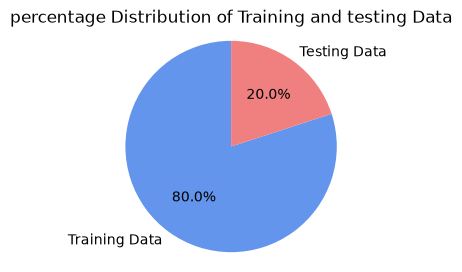

In [28]:
labels = ['Training Data' , 'Testing Data']
sizes = [train_percentage,test_percentage]
colors = ['cornflowerblue','lightcoral']
plt.figure(figsize = (3,3))
plt.pie(sizes,labels = labels,autopct = '%1.1f%%',startangle = 90,colors = colors)
plt.title('percentage Distribution of Training and testing Data')
plt.axis('equal')
plt.show()

In [29]:
train_label_counts = Counter(train_labels)
test_label_counts = Counter(test_labels)
train_classes = sorted(train_label_counts.keys())
train_counts = [train_label_counts[cls] for cls in train_classes]

test_classes = sorted(test_label_counts.keys())
test_counts = [test_label_counts[cls] for cls in test_classes]

In [30]:
train_label_counts = Counter(train_labels)
test_label_counts = Counter(test_labels)
train_classes = sorted(train_label_counts.keys())
train_counts = [train_label_counts[cls] for cls in train_classes] # This resets it back to a list!

test_classes = sorted(test_label_counts.keys())
test_counts = [test_label_counts[cls] for cls in test_classes]

In [31]:
total_train = sum(train_counts)
total_test = sum(test_counts)

train_percentage = [(count / total_train) * 100 for count in train_counts]
test_percentage = [(count / total_test) * 100 for count in test_counts]

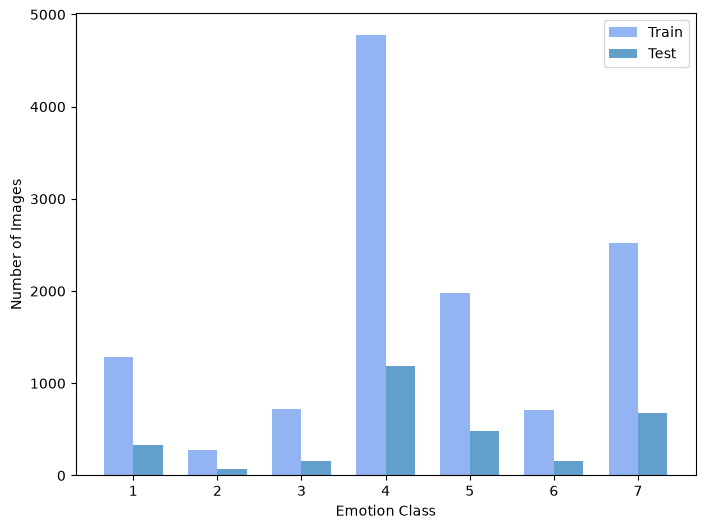

In [32]:
plt.figure(figsize=(8,6))

# FIX 1: Use train_classes since 'classes' isn't defined
x = range(len(train_classes)) 
bar_width = 0.35

plt.bar(x, train_counts, width=bar_width, label='Train', alpha=0.7, color='cornflowerblue')

# FIX 2: Fixed typo from 'bar_widh' to 'bar_width'
plt.bar([p + bar_width for p in x], test_counts, width=bar_width, label='Test', alpha=0.7) 

# Optional additions to make your graph look identical to the video
plt.xlabel('Emotion Class')
plt.ylabel('Number of Images')
plt.xticks([p + bar_width/2 for p in x], train_classes)
plt.legend()

plt.show()

In [33]:
from collections import Counter

# 1. Count instances per class
train_label_counts = Counter(train_labels)
test_label_counts = Counter(test_labels)

train_classes = sorted(list(train_label_counts.keys()))
train_counts = [train_label_counts[cls] for cls in train_classes]

test_classes = sorted(list(test_label_counts.keys()))
test_counts = [test_label_counts[cls] for cls in test_classes]

# 2. Compute percentages safely
total_train = sum(train_counts) if sum(train_counts) > 0 else 1
total_test = sum(test_counts) if sum(test_counts) > 0 else 1

train_percentage = [(count / total_train) * 100 for count in train_counts]
test_percentage = [(count / total_test) * 100 for count in test_counts]

print("Train counts:", train_counts)
print("Test counts:", test_counts)

Train counts: [1290, 281, 717, 4772, 1982, 705, 2524]
Test counts: [329, 74, 160, 1185, 478, 162, 680]


--- Loading Images ---
✓ Loaded 12271 Train images.
✓ Loaded 3068 Test images.


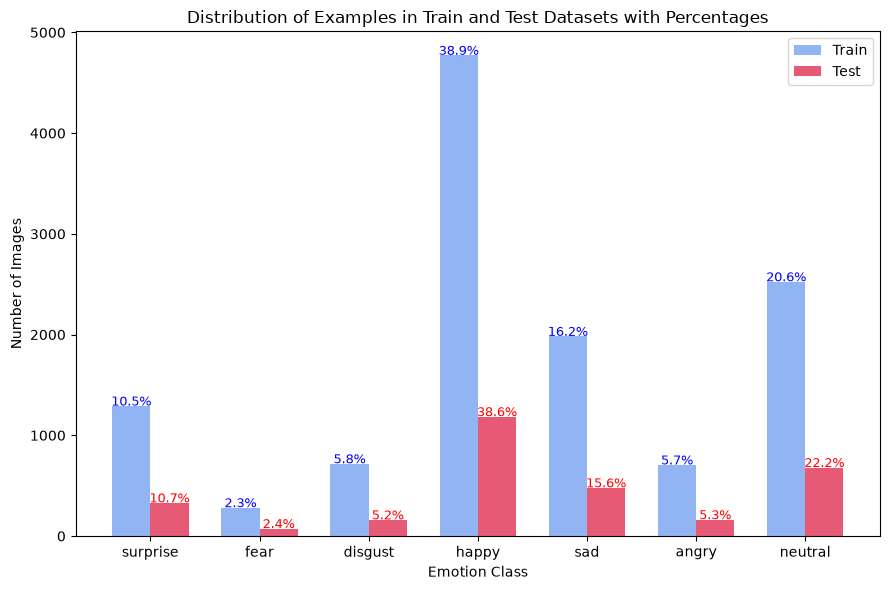

In [39]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Exact Absolute Paths matching your system layout
TRAIN_DIR = r"c:\Users\Dell\Desktop\Emotional_Detector.project\DATASET\train"
TEST_DIR = r"c:\Users\Dell\Desktop\Emotional_Detector.project\DATASET\test"

# Folders ka map (1 se 7)
label_map = {
    'surprise': 1, 'fear': 2, 'disgust': 3, 'happy': 4, 'sad': 5, 'angry': 6, 'neutral': 7
}
classes = list(label_map.keys())

# 2. Simple Data Loader
def load_data(dataset_dir):
    images, labels = [], []
    if not os.path.exists(dataset_dir):
        print(f"⚠️ Error: Path nahi mila -> {dataset_dir}")
        return np.array(images), np.array(labels)
        
    for label_name, folder_num in label_map.items():
        folder_path = os.path.join(dataset_dir, str(folder_num))
        if os.path.exists(folder_path):
            for filename in os.listdir(folder_path):
                img = cv2.imread(os.path.join(folder_path, filename))
                if img is not None:
                    images.append(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
                    labels.append(folder_num)
    return np.array(images), np.array(labels)

# Data load karo
print("--- Loading Images ---")
train_images, train_labels = load_data(TRAIN_DIR)
test_images, test_labels = load_data(TEST_DIR)

print(f"✓ Loaded {len(train_images)} Train images.")
print(f"✓ Loaded {len(test_images)} Test images.")

# 3. Counts and Percentages nikalne ka logic
train_counts = [np.sum(train_labels == i) for i in range(1, 8)]
test_counts = [np.sum(test_labels == i) for i in range(1, 8)]

total_train = len(train_images)
total_test = len(test_images)

train_percentage = [(c / total_train) * 100 if total_train > 0 else 0 for c in train_counts]
test_percentage = [(c / total_test) * 100 if total_test > 0 else 0 for c in test_counts]

# 4. Simple Plot Graph
plt.figure(figsize=(9, 6))
x = np.arange(len(classes))
bar_width = 0.35

plt.bar(x, train_counts, width=bar_width, label='Train', alpha=0.7, color='cornflowerblue')
plt.bar(x + bar_width, test_counts, width=bar_width, label='Test', alpha=0.7, color='crimson')

# Add text labels over bars
for i, count in enumerate(train_counts):
    if count > 0:
        plt.text(i, count + 5, f"{train_percentage[i]:.1f}%", ha='center', color='blue', fontsize=9)

for i, count in enumerate(test_counts):
    if count > 0:
        plt.text(i + bar_width, count + 5, f"{test_percentage[i]:.1f}%", ha='center', color='red', fontsize=9)

plt.xlabel('Emotion Class')
plt.ylabel('Number of Images')
plt.title('Distribution of Examples in Train and Test Datasets with Percentages')
plt.xticks(x + bar_width / 2, classes) 
plt.legend()
plt.tight_layout()
plt.show()

In [40]:
x_train = np.concatenate([train_images,test_images], axis = 0)
y_train = np.concatenate([train_labels,test_labels],axis = 0)
print(x_train.shape)
print(y_train.shape)

(15339, 100, 100, 3)
(15339,)


In [41]:
x_train,y_train = shuffle(x_train,y_train,random_state=42)

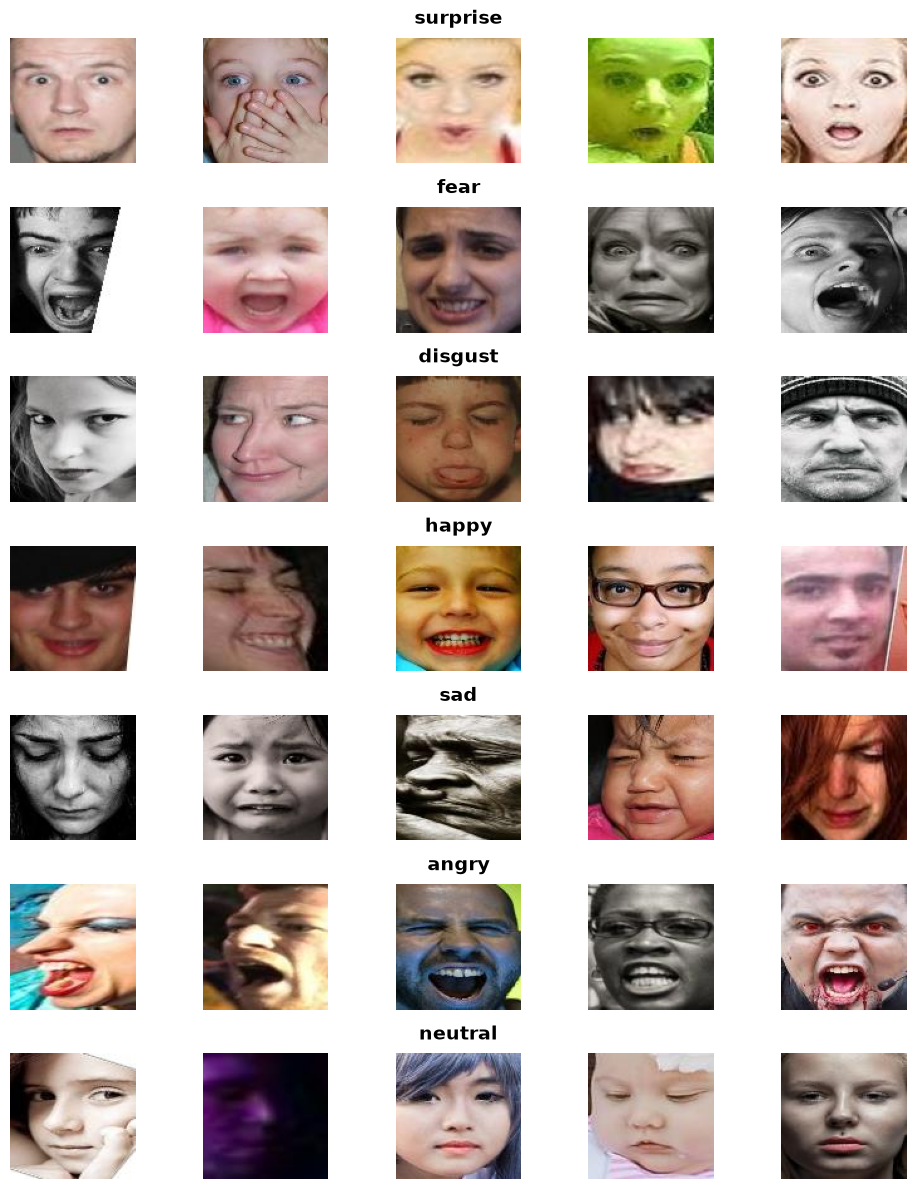

In [42]:
def show_examples(train_images, train_labels, labels, num_examples = 5):
    num_classes = len(classes)
    fig, axs = plt.subplots(num_classes, num_examples, figsize=(10, 12))
    
    for i, class_name in enumerate(classes):
        # 1. Get the indices for the current class
        class_indices = [idx for idx, label in enumerate(train_labels) if label == i+1]
        
        # 2. Pick random images for this class
        selected_indices = np.random.choice(class_indices, num_examples, replace = False)
        
        # FIX: Changed axs[1,0] to axs[i,2] to center the title over the middle image of row 'i'
        axs[i, 2].set_title(class_name, fontsize = 14, pad = 10, fontweight = 'bold')
        
        for j, idx in enumerate(selected_indices):
            img = train_images[idx]
            axs[i, j].imshow(img)
            axs[i, j].axis('off')
            
    plt.tight_layout()
    plt.show()

# Call the function exactly as you did before
show_examples(x_train, y_train, classes)

In [43]:
train_data_shapes = []
for img in x_train:
    train_data_shapes.append(img.shape)

shape_counts = {}
for shape in train_data_shapes:
    if shape not in shape_counts:
        shape_counts[shape] =0
    shape_counts[shape] +=1 
sorted_shapes = sorted(shape_counts.items(),key = lambda x:x[1],reverse = True)
print("Most frequent Train images shapes")
for shape,count in sorted_shapes[:3]:
    print(f"-{shape} : {count}")




Most frequent Train images shapes
-(100, 100, 3) : 15339


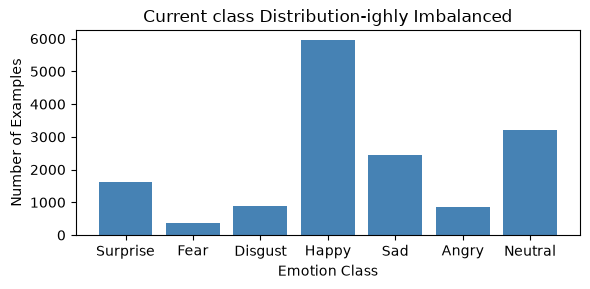

In [44]:


def plot_class_distribution(y, title):
    train_label_counts_resampled = Counter(y)
    
    train_classes_resampled = sorted(train_label_counts_resampled.keys())
    train_counts_resampled = [train_label_counts_resampled[cls] for cls in train_classes_resampled]
    
    plt.figure(figsize=(6, 3))
    x_labels = ['Surprise', 'Fear', 'Disgust', 'Happy', 'Sad', 'Angry', 'Neutral']
    
    plt.bar(x_labels, train_counts_resampled, color="steelblue")
    
    plt.xlabel("Emotion Class")
    plt.ylabel("Number of Examples")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_class_distribution(y_train,"Current class Distribution-ighly Imbalanced")

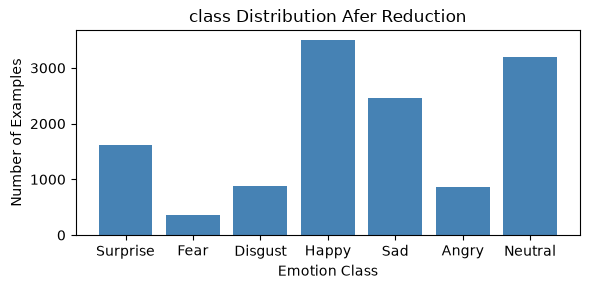

In [47]:
def reduce_class(x,y,target_class,target_size):
    class_indices = np.where(y==target_class)[0]
    non_class_indices = np.where(y !=target_class)[0]

    reduced_class_indices = np.random.choice(class_indices,target_size,replace = False)

    final_indices = np.concatenate([reduced_class_indices,non_class_indices])
    x_reduced = x[final_indices]
    y_reduces = y[final_indices]

    return x_reduced,y_reduces

target_class = 4
target_size = 3500
x_train_reduced,y_train_reduced = reduce_class(x_train,y_train,target_class,target_size)
plot_class_distribution(y_train_reduced,"class Distribution Afer Reduction")

In [48]:


def augment_class(images, labels, target_counts):
    datagen = ImageDataGenerator(
        rotation_range = 10,
        width_shift_range = 0.1,
        height_shift_range = 0.1,
        zoom_range = 0.1,
        vertical_flip = False,
        horizontal_flip = True,
        channel_shift_range = 50.0,
        fill_mode = "nearest"
    )

    # FIX 1: Fixed spelling from 'augemented_labels' to 'augmented_labels'
    augmented_images = images.copy()
    augmented_labels = labels.copy()

    for target_class, target_count in target_counts.items():
        class_images = images[labels == target_class]
        
        # Keras flow needs 4D arrays (Num_images, Height, Width, Channels)
        # If your images are already 4D, this line won't hurt
        if class_images.ndim == 3:
            class_images = np.expand_dims(class_images, axis=-1)
            
        augment_count = target_count - len(class_images)
        
        if augment_count > 0:
            print(f"Class {target_class}: {len(class_images)} original samples, augmenting with {augment_count} new samples.")
            class_images_augmented = []
            class_labels_augmented = []

            # Using a dynamic batch loop stream
            for batch in datagen.flow(class_images, batch_size=1, seed=42):
                # FIX 2: Fixed typo from 'aug_iamges' to 'aug_images'
                aug_images = batch[0].astype(np.uint8)
                class_images_augmented.append(aug_images)
                class_labels_augmented.append(target_class)

                if len(class_images_augmented) >= augment_count:
                    break

            # Combine data safely
            augmented_images = np.vstack((augmented_images, np.array(class_images_augmented)))
            augmented_labels = np.hstack((augmented_labels, np.array(class_labels_augmented)))
            
    return augmented_images, augmented_labels

# --- Execution ---
target_count = {1: 3500, 2: 3500, 3: 3500, 4: 3500, 5: 3500, 6: 3500, 7: 3500}

# FIX 3: Changed comma (,) to equals sign (=) to store the return outputs properly
x_train_augmented, y_train_augmented = augment_class(x_train_reduced, y_train_reduced, target_count)

Class 1: 1619 original samples, augmenting with 1881 new samples.
Class 2: 355 original samples, augmenting with 3145 new samples.
Class 3: 877 original samples, augmenting with 2623 new samples.
Class 5: 2460 original samples, augmenting with 1040 new samples.
Class 6: 867 original samples, augmenting with 2633 new samples.
Class 7: 3204 original samples, augmenting with 296 new samples.


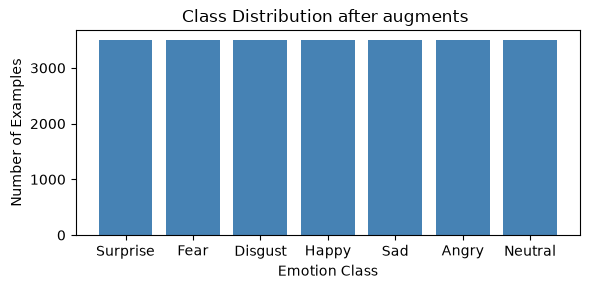

In [49]:
plot_class_distribution(y_train_augmented,'Class Distribution after augments ')

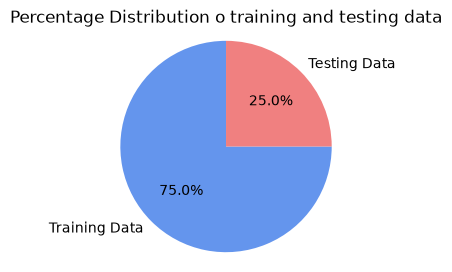

In [50]:
x_train,x_test,y_train,y_test =train_test_split(x_train_augmented,
                                                y_train_augmented,
                                                test_size=0.25,
                                                shuffle=True,
                                                random_state=42)
total_image = len(x_train) + len(x_test)
train_percentage = (len(x_train) / total_image) *100
test_percentage = (len(x_test) / total_image) * 100
labels = ['Training Data' , 'Testing Data']
sizes = [train_percentage,test_percentage]
colors = ['cornflowerblue','lightcoral']

plt.figure(figsize=(3,3))
plt.pie(sizes,labels=labels,autopct='%1.1f%%',startangle=90,colors=colors)
plt.title('Percentage Distribution o training and testing data')
plt.axis('equal')
plt.show()

In [51]:
def normalize_images(images):
    return images/255.0
train_images_normalized = normalize_images(x_train)
test_images_normalized = normalize_images(x_test)


In [52]:
def reshape_images(images):
    return images.reshape((images.shape[0],100,100,3))

train_images_reshaped = reshape_images(train_images_normalized)
test_image_reshaped = reshape_images(test_images_normalized)

In [53]:
print(f"Training images shape : {train_images_reshaped.shape}")
print(f"Testing images shape: {test_image_reshaped.shape}")

Training images shape : (18375, 100, 100, 3)
Testing images shape: (6125, 100, 100, 3)


In [54]:
y_train_cat = to_categorical(y_train - 1, num_classes=len(classes))
y_test_cat = to_categorical(y_test - 1 , num_classes=len(classes))

In [55]:


# 1. FIX: Create the missing reshaped variable using your current augmented training images
# If your images don't have the final channel color dimension, expand them
if x_train_augmented.ndim == 3:
    train_images_CNNreshaped = np.expand_dims(x_train_augmented, axis=-1)
else:
    train_images_CNNreshaped = x_train_augmented

# 2. FIX: Make sure your target labels are converted to categorical (one-hot encoded)
# Subtracting 1 if your class labels are 1-7 to convert them to 0-6 index positioning
y_train_cat = to_categorical(y_train_augmented - 1, num_classes=len(classes))

# 3. Define the ImageDataGenerator setup exactly like the instructor
datagen = ImageDataGenerator(
    rotation_range = 20,
    width_shift_range = 0.1,
    height_shift_range = 0.1,
    vertical_flip = False,
    fill_mode = 'nearest'
)

# 4. Generate the flow batch stream securely
train_generator = datagen.flow(train_images_CNNreshaped, y_train_cat, batch_size=64)



In [57]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [58]:


# Define the CNN model
cnn_model = Sequential([
    # First Convolutional Layer
    Conv2D(32, (3, 3), activation='relu', input_shape=(train_images_CNNreshaped[0].shape)),
    MaxPooling2D((2, 2)),
    
    # Second Convolutional Layer
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    
    # Third Convolutional Layer
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    
    # Fourth Convolutional Layer
    Conv2D(512, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    
    # Flattening and Dense Hidden Layers
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    
    # Output Layer matching your 7 classes
    Dense(len(classes), activation='softmax')
])

# Compile the CNN model
cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Display the architecture summary
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 98, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 512)      │       590,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │         3,591 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,881,991 (18.62 MB)

 Trainable params: 4,881,991 (18.62 MB)

 Non-trainable params: 0 (0.00 B)

## model evalution

In [59]:
# 1. FIX: Format test labels properly (convert 1-7 classes to 0-6 categorical values)
# Using your initial testing split target variables 'test_labels' or 'v_labels'
y_test_cat = to_categorical(test_labels - 1, num_classes=len(classes))

# 2. FIX: Format test images properly (ensure channel dimension is present)
if test_images.ndim == 3:
    test_images_CNNreshaped = np.expand_dims(test_images, axis=-1)
else:
    test_images_CNNreshaped = test_images

# 3. Define your training mechanics callbacks
reduce_lr = ReduceLROnPlateau(monitor='val_accuracy', factor=0.1, patience=10, min_delta=0.001, verbose=1)
early_stop = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint(filepath='best_CNNModel.keras', monitor='val_accuracy', save_best_only=True)

# 4. FIX: Pass the corrected 'test_images_CNNreshaped' matching your test label array length
CNN_History = cnn_model.fit(
    train_generator,
    epochs=10,
    batch_size=32, # Note: train_generator already controls training batch sizes (64)
    validation_data=(test_images_CNNreshaped, y_test_cat), # Fixed: both arrays are matching test lengths now
    callbacks=[reduce_lr, early_stop, checkpoint]
)


Epoch 1/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 92s 234ms/step - accuracy: 0.2580 - loss: 2.3777 - val_accuracy: 0.4498 - val_loss: 1.5421 - learning_rate: 0.0010
Epoch 2/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 88s 229ms/step - accuracy: 0.3533 - loss: 1.6733 - val_accuracy: 0.5528 - val_loss: 1.2268 - learning_rate: 0.0010
Epoch 3/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 89s 232ms/step - accuracy: 0.4270 - loss: 1.5257 - val_accuracy: 0.5831 - val_loss: 1.1516 - learning_rate: 0.0010
Epoch 4/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 93s 242ms/step - accuracy: 0.4800 - loss: 1.3923 - val_accuracy: 0.6271 - val_loss: 1.0388 - learning_rate: 0.0010
Epoch 5/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 89s 233ms/step - accuracy: 0.5222 - loss: 1.2961 - val_accuracy: 0.6610 - val_loss: 0.9605 - learning_rate: 0.0010
Epoch 6/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 87s 227ms/step - accuracy: 0.5388 - loss: 1.2332 - val_accuracy: 0.6532 - val_loss: 0.9795 - learning_rate: 0.0010
Epoch 7/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 88s 228ms/step - accuracy: 0.5

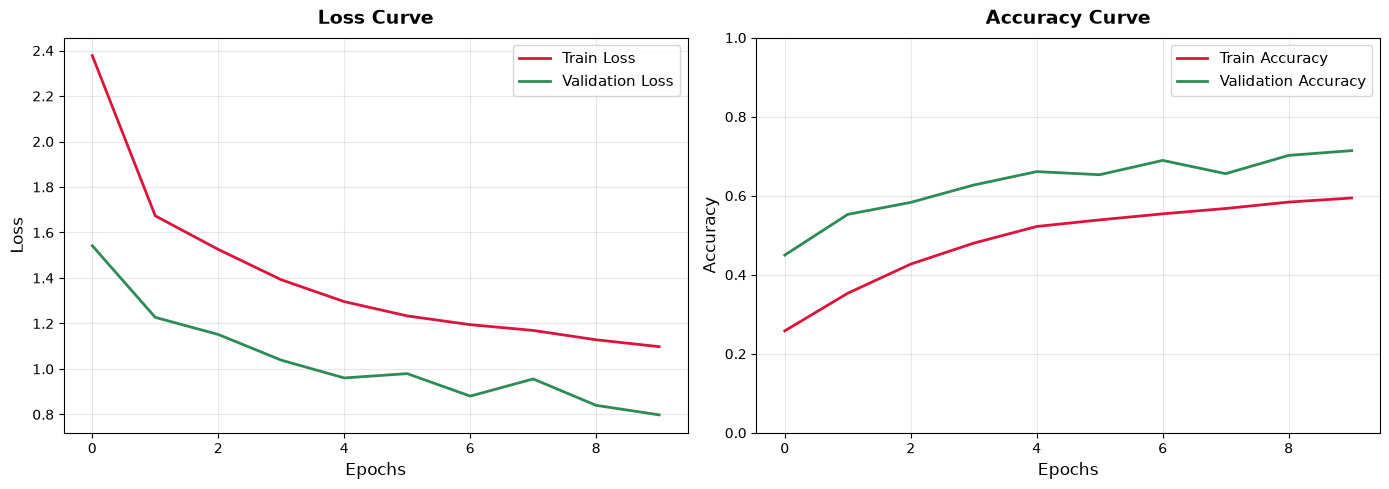

In [60]:
train_loss = CNN_History.history['loss']
val_loss = CNN_History.history['val_loss']
train_accuracy =CNN_History.history['accuracy']
val_accuracy = CNN_History.history['val_accuracy']
# 1. Create a side-by-side plot layout (1 row, 2 columns)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# 2. LEFT GRAPH: LOSS CURVE
# Plotting Train Loss vs Validation Loss
ax[0].plot(CNN_History.history['loss'], label='Train Loss', color='crimson', linewidth=2)
ax[0].plot(CNN_History.history['val_loss'], label='Validation Loss', color='seagreen', linewidth=2)

ax[0].set_title('Loss Curve', fontsize=14, fontweight='bold', pad=10)
ax[0].set_xlabel('Epochs', fontsize=12)
ax[0].set_ylabel('Loss', fontsize=12) # Fixed: Changed from Accuracy to Loss
ax[0].grid(alpha=0.3)
ax[0].legend(fontsize=11)

# 3. RIGHT GRAPH: ACCURACY CURVE
# Plotting Train Accuracy vs Validation Accuracy
ax[1].plot(CNN_History.history['accuracy'], label='Train Accuracy', color='crimson', linewidth=2)
ax[1].plot(CNN_History.history['val_accuracy'], label='Validation Accuracy', color='seagreen', linewidth=2)

ax[1].set_title('Accuracy Curve', fontsize=14, fontweight='bold', pad=10) # Fixed: Corrected spelling
ax[1].set_xlabel('Epochs', fontsize=12)
ax[1].set_ylabel('Accuracy', fontsize=12)
ax[1].set_ylim([0, 1]) # Sets accuracy limits between 0% and 100%
ax[1].grid(alpha=0.3)
ax[1].legend(fontsize=11)

# 4. Render Layout cleanly
plt.tight_layout()
plt.show()

In [61]:
train_CNNresult = cnn_model.evaluate(train_images_CNNreshaped,y_train_cat)
test_CNNresult = cnn_model.evaluate(test_images_CNNreshaped,y_test_cat)

print("Training loss {:.2f}%".format(train_CNNresult[0]*100))
print("Training accuracy {:.2f}%".format(train_CNNresult[1]*100))

print("\nTest loss : {:.2f}".format(test_CNNresult[0]*100))
print("test accuracy : {:.2f}%".format(test_CNNresult[1] * 100))

766/766 ━━━━━━━━━━━━━━━━━━━━ 22s 29ms/step - accuracy: 0.6866 - loss: 0.8567
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.7141 - loss: 0.7981
Training loss 85.67%
Training accuracy 68.66%

Test loss : 79.81
test accuracy : 71.41%


In [62]:
# 1. Save the trained architecture and weights
cnn_model.save('final_emotion_model.keras')

# 2. Save the classes list using joblib to preserve string mapping order
import joblib
joblib.dump(classes, 'emotion_classes.pkl')

print("Model and classes saved successfully!")

Model and classes saved successfully!
